# Sentiment Analysis of IMDB Movie Reviews Using NLP

## Objective
The objective of this project is to perform sentiment analysis on movie reviews using Natural Language Processing techniques and Machine Learning algorithms to classify reviews as positive or negative.

## Technologies Used
- Python
- Pandas
- NLTK
- Scikit-learn
- TF-IDF Vectorizer
- Logistic Regression
- Matplotlib
- Jupyter Notebook

## Importing Required Libraries

In this section, all necessary libraries for data manipulation, text preprocessing, machine learning, and evaluation are imported.

In [1]:
# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization library
import matplotlib.pyplot as plt

# Import regular expressions for text cleaning
import re

# Import Natural Language Processing library
import nltk
from nltk.corpus import stopwords

# Import machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Import machine learning model
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Downloading Stopwords

Stopwords are commonly used words such as "the", "is", and "and" that usually do not contribute significantly to sentiment analysis.

In [2]:
# Download stopwords dataset
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\parthiv
[nltk_data]     reddy\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## Loading the Dataset

The IMDB movie reviews dataset contains textual movie reviews along with their sentiment labels.

In [3]:
# Load IMDB dataset
df = pd.read_csv(r"C:\Users\parthiv reddy\OneDrive\Desktop\sentiment Ana_task4\IMDB Dataset.csv")

# Display confirmation message
print("Dataset loaded successfully!")

Dataset loaded successfully!


## Dataset Exploration

The dataset is explored to understand its structure, dimensions, and data types.

In [4]:
# Display first five records
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Display dataset dimensions
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 2)


In [6]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
# Check for missing values
df.isnull().sum()

review       0
sentiment    0
dtype: int64

## Encoding Sentiment Labels

The sentiment labels are converted into numerical values for machine learning model training.

In [8]:
# Convert sentiment labels into numerical values
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

# Display class distribution
df['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

## Text Preprocessing

The review text is cleaned by:
- Converting text to lowercase
- Removing HTML tags
- Removing punctuation and numbers
- Removing stopwords

In [10]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

# Function to clean review text
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

## Applying Text Cleaning

The preprocessing function is applied to all reviews to prepare the data for feature extraction.

In [11]:
# Apply text cleaning to all reviews
df['clean_review'] = df['review'].apply(clean_text)

# Display sample cleaned reviews
df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


## Feature Extraction using TF-IDF Vectorization

Machine learning models cannot understand text directly. Therefore, textual reviews are converted into numerical vectors using TF-IDF Vectorization.

In [12]:
# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Convert text data into numerical vectors
X = tfidf.fit_transform(df['clean_review'])

# Target variable
y = df['sentiment']

# Display feature matrix shape
print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (50000, 5000)
Target Variable Shape: (50000,)


## Splitting Dataset into Training and Testing Sets

The dataset is divided into training and testing datasets to evaluate the model's performance on unseen data.

In [13]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display dataset dimensions
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (40000, 5000)
Testing Data Shape: (10000, 5000)


## Training Logistic Regression Model

A Logistic Regression model is trained to classify movie reviews as positive or negative.

In [14]:
# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# Generate predictions
predictions = model.predict(X_test)

print("Model training completed successfully!")

Model training completed successfully!


## Model Evaluation

The model performance is evaluated using accuracy score, confusion matrix, and classification report.

In [15]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8874


In [16]:
# Generate confusion matrix
cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4328  633]
 [ 493 4546]]


In [17]:
# Generate classification report
report = classification_report(y_test, predictions)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## Visualization of Model Performance

The model accuracy is visualized using a bar chart.

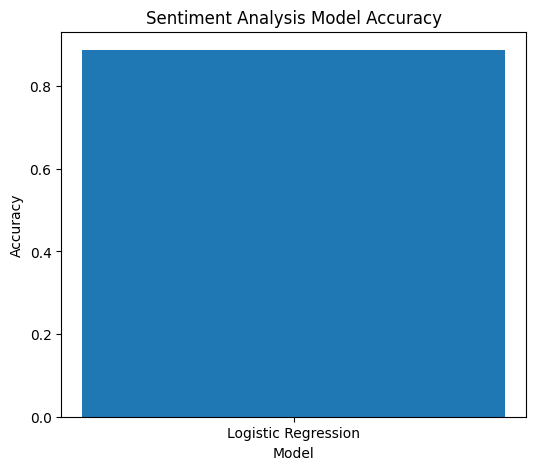

In [18]:
# Create accuracy visualization
plt.figure(figsize=(6,5))

plt.bar(
    ["Logistic Regression"],
    [accuracy]
)

plt.title("Sentiment Analysis Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

# Conclusion

This project successfully implemented sentiment analysis on 50,000 IMDB movie reviews using Natural Language Processing techniques.

## Key Findings

- The dataset contained 50,000 movie reviews.
- Text preprocessing improved the quality of textual data.
- TF-IDF Vectorization converted textual data into numerical features.
- Logistic Regression successfully classified reviews into positive and negative sentiments.
- The model achieved high classification accuracy.

## Technologies Used

- Python
- Pandas
- NLTK
- Scikit-learn
- TF-IDF Vectorizer
- Logistic Regression

## Results

The Logistic Regression model achieved an accuracy of **88.74%** on the test dataset.

### Confusion Matrix

| Actual Class | Predicted Negative | Predicted Positive |
|-------------|-------------------|-------------------|
| Negative | 4328 | 633 |
| Positive | 493 | 4546 |

The model demonstrated strong performance in distinguishing positive and negative movie reviews.